# Home Depot twice-calibration

**Question 1 — does per-collection post-training beat the constant?** Warm-start
the deployed router on N judged Home Depot queries; compare on a frozen eval
holdout against the sparse constant, the base router, threshold-only
recalibration, and the oracle.

**Question 2 — does synthetic calibration match real calibration?** Mint N
queries from the product corpus (qrels by construction), post-train the same
way (Arm S), and compare against Arm R on the SAME eval holdout.

Decision rules (pre-committed):
- *beats constant*: seed-mean Δrel@1 vs sparse > 0, same sign on ≥4/5 seeds,
  Wilcoxon p<0.05 on the median seed.
- *S ≈ R*: |meanΔ(R) − meanΔ(S)| ≤ max(0.015 rel@1, 1 pooled seed-sd).
- The placebo (shuffled labels) must NOT beat the constant, or the experiment
  is invalid.

Inputs are produced by (run in order, post fusion query_embed fix):
```
poetry run python src/scripts/materialize_corpora.py --only home-depot
poetry run python src/scripts/retrieve_home_depot_routes.py
poetry run python src/scripts/derive_home_depot_labels.py
```
All numbers here are post-fix and NOT comparable to `home_depot_top1_bakeoff`
(pre-fix sparse leg, unrecoverable router arm). The base arm is pinned in the
config cell and echoed in every artifact.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

REPO = Path.cwd().resolve()
while not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
DATA = REPO / "src" / "data"
HD = DATA / "home-depot"

LABELS_REAL = HD / "route_labels_real.parquet"
LABELS_MINTED = HD / "route_labels_minted.parquet"
RANKINGS_REAL = HD / "route_rankings_full.parquet"
QRELS = HD / "qrels.parquet"
QUERIES = HD / "queries.parquet"
SPLIT = HD / "twice_calibration_split.parquet"
FEATURES_REAL = HD / "features_deployed_arm.parquet"
FEATURES_MINTED = HD / "features_deployed_arm_minted.parquet"
MINT_SOURCE = HD / "mint_source"
MINTED_QUERIES = HD / "minted_queries.parquet"
MINTED_QRELS = HD / "minted_qrels.parquet"
RESULTS = HD / "twice_calibration_results.parquet"

from encoder_router.table import MODELS_DIR  # noqa: E402

BASE_ARM = MODELS_DIR / "classifiers_union_200k" / "zipf_shape_nocorpus"
OUT_ARMS = MODELS_DIR / "home_depot_calibration"  # never the deploy library

EVAL_N = 2_000
N_GRID = (100, 300, 1_000)
SEEDS = tuple(range(5))
BASE_DELTA = 0.15
DELTA_GRID = np.round(np.arange(0.0, 0.31, 0.05), 2)
MIN_DIFFER_FOR_TUNE = 20  # fewer routes_differ rows than this -> keep base thresholds
SPLIT_SEED = 0
ROUTES = ("dense_only", "pure_rrf", "sparse_only")

RUN_MINT = True       # flip for the one LLM minting pass (hard cap below)
RUN_COHERENCE = True  # 30-row coherence pilot (~$0.10)
MINT_N = 1_300         # slack over the 1_000 max-N for filtering losses
MINT_BUDGET_USD = 8.0
FORCE_SPLIT = False    # the eval holdout is frozen; True re-draws it


## Stage 1 — labels, frozen split, per-query metrics

The split is written once and reused by every later run. Eval rows are touched
only in the final readout; every tuned quantity (weights, thresholds, delta,
constant picks) sees calibration rows only.


In [2]:
from hybrid_search_rrf_dataset.labels import AcceptabilityLabels

assert LABELS_REAL.exists(), "run the three input commands from the header first"
labels_real = pd.read_parquet(LABELS_REAL).astype({"query_id": str})
frame_real = AcceptabilityLabels(labels_real).frame().set_index(
    "query_id", drop=False
)
print(f"{len(frame_real):,} labelled queries")
print(frame_real["shape"].value_counts().to_string())
print("constant means (post-fix bar):",
      {r: round(float(frame_real[f"score_{r}"].mean()), 4) for r in ROUTES})


11,795 labelled queries
shape
routes_differ    7445
all_zero         4119
all_tied          231
constant means (post-fix bar): {'dense_only': 0.1443, 'pure_rrf': 0.2145, 'sparse_only': 0.2437}


In [3]:
from encoder_router.table import ZipfStats

if SPLIT.exists() and not FORCE_SPLIT:
    split = pd.read_parquet(SPLIT).astype({"query_id": str})
else:
    z = ZipfStats().frame(frame_real["query"].reset_index(drop=True))
    rare = z["zipf.rare_share"].to_numpy()
    bins = pd.qcut(rare, 5, labels=False, duplicates="drop")
    ids = frame_real["query_id"].to_numpy()
    rng = np.random.default_rng(SPLIT_SEED)
    chosen: list[str] = []
    for b in np.unique(bins):
        members = ids[bins == b]
        take = int(round(EVAL_N * len(members) / len(ids)))
        chosen.extend(rng.choice(members, size=min(take, len(members)),
                                 replace=False))
    eval_set = set(map(str, chosen))
    split = pd.DataFrame({
        "query_id": ids, "rare_bin": bins,
        "split": ["eval" if i in eval_set else "calibration" for i in ids],
    })
    split.to_parquet(SPLIT, index=False)
    print("split written")

eval_ids = split.loc[split["split"] == "eval", "query_id"].tolist()
cal_ids = split.loc[split["split"] == "calibration", "query_id"].tolist()
print(split["split"].value_counts().to_dict())


{'calibration': 9796, 'eval': 1999}


In [4]:
# per-query metric matrix: rel@1 (graded, <2 zeroed), hit@1, captured objective
# score, per route — plus oracle columns over exactly the 3 base routes with the
# SAME zeroing, fixing both bakeoff protocol asymmetries.
rankings = pd.read_parquet(RANKINGS_REAL).astype({"query_id": str, "doc_id": str})
qrels = pd.read_parquet(QRELS).astype({"query_id": str, "doc_id": str})
grade = {
    (q, d): float(r)
    for q, d, r in zip(qrels["query_id"], qrels["doc_id"], qrels["relevance"])
}

top1 = rankings[rankings["rank"] == 0]
metrics = pd.DataFrame(index=frame_real.index)
for route in ROUTES:
    at1 = top1.loc[top1["route"] == route].set_index("query_id")["doc_id"]
    g = np.array([grade.get((q, at1.get(q, "")), 0.0) for q in metrics.index])
    metrics[f"rel1_{route}"] = np.where(g >= 2.0, g, 0.0)
    metrics[f"hit1_{route}"] = (g >= 2.0).astype(float)
    metrics[f"captured_{route}"] = frame_real[f"score_{route}"]
for m in ("rel1", "hit1", "captured"):
    metrics[f"{m}_oracle"] = metrics[[f"{m}_{r}" for r in ROUTES]].max(axis=1)

eval_metrics = metrics.loc[eval_ids]
print(eval_metrics.filter(regex="^rel1").mean().round(4).to_string())


rel1_dense_only     0.3337
rel1_pure_rrf       0.5146
rel1_sparse_only    0.6063
rel1_oracle         0.7923


## Stage 2 — featurize through the deployed arm's frozen transforms

One featurizer for every query (real and minted): the pinned arm's bge
encoder + saved SVD basis + saved zipf/shape z-stats, exactly the 522-dim
space its weights were trained in. Cached to parquet — delete the cache file
to re-embed.


In [5]:
from router_service.serve import SavedRouter

router0 = SavedRouter.load(BASE_ARM)
BASE_THRESHOLDS = np.load(BASE_ARM / "thresholds.npy")
print("pinned arm:", router0.meta.get("arm"),
      "| trained_at:", router0.meta.get("trained_at"),
      "| thresholds:", BASE_THRESHOLDS.tolist(), "| delta:", BASE_DELTA)


def featurize(queries: pd.Series, cache: Path) -> np.ndarray:
    """queries: text indexed by query_id; rows come back in that order."""
    if cache.exists():
        cached = pd.read_parquet(cache).set_index("query_id")
        if set(queries.index) <= set(cached.index):
            return cached.loc[queries.index].to_numpy(np.float32)
    texts = queries.tolist()
    blocks = [
        router0._inputs(texts[start:start + 256])
        for start in tqdm(range(0, len(texts), 256), desc=cache.stem)
    ]
    x = np.concatenate(blocks)
    out = pd.DataFrame(x, columns=[str(i) for i in range(x.shape[1])])
    out.insert(0, "query_id", list(queries.index))
    out.to_parquet(cache, index=False)
    return x.astype(np.float32)


X_real = featurize(frame_real["query"], FEATURES_REAL)
pos_real = {q: i for i, q in enumerate(frame_real.index)}
print("features:", X_real.shape)


pinned arm: zipf_shape_nocorpus | trained_at: 2026-09-08 13:52:10 | thresholds: [0.30000001192092896, 0.8999999761581421] | delta: 0.15
features: (11795, 522)


## Stage 3 — minting (Arm S inputs; LLM spend, gated)

Mint queries from the product corpus. The mint source dir carries the corpus
plus **calibration-pool queries only** as style exemplars, so eval text never
reaches a prompt. After minting: 30-row coherence pilot, near-dup filter
against the eval set, export, then re-run the retrieval + label scripts with
the minted files (commands printed below).


In [6]:
# mint source: corpus + calibration-only exemplars (eval text never in a prompt)
MINT_SOURCE.mkdir(exist_ok=True)
link = MINT_SOURCE / "corpus.parquet"
if not link.exists():
    link.symlink_to((HD / "corpus.parquet").resolve())
lane_queries = pd.read_parquet(QUERIES).astype({"query_id": str})
lane_queries[lane_queries["query_id"].isin(set(cal_ids))].to_parquet(
    MINT_SOURCE / "queries.parquet", index=False
)
print("mint source ready:", MINT_SOURCE)


mint source ready: /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/home-depot/mint_source


In [7]:
if RUN_MINT:
    from augmentation.config import AugmentationConfig
    from augmentation.engine import Budget
    from augmentation.loop import AugmentationLoop

    config = AugmentationConfig()
    budget = Budget(MINT_BUDGET_USD,
                    usd_per_mtok_in=config.engine.usd_per_mtok_in,
                    usd_per_mtok_out=config.engine.usd_per_mtok_out)
    loop = AugmentationLoop(
        pd.DataFrame(columns=["dataset", "query_id", "query", "checkable"]),
        config=config, budget=budget,
    )
    minted = loop.synthesize_lane("home-depot", MINT_N, source_dir=MINT_SOURCE)
    print(f"minted {len(minted)} | spent ${budget.spent_usd:.2f} "
          f"of ${MINT_BUDGET_USD}")
else:
    print(f"RUN_MINT=False — flip to mint {MINT_N} queries "
          f"(1 LLM call/row, hard cap ${MINT_BUDGET_USD})")


lane:home-depot:   0%|          | 0/1300 [00:00<?, ?row/s]

+ lane-home-depot-0: 'how to grow orchids guide'
+ lane-home-depot-1: 'hardwood dowels'
+ lane-home-depot-2: 'retractable hose reel 50 ft'
+ lane-home-depot-3: 'aluminum handrail kit 4 ft'
+ lane-home-depot-4: 'outdoor chair cushions patio high back'
+ lane-home-depot-5: 'large marble wall fountain with stainless steel trim'
- lane-home-depot-6: dropped — verbatim from the grounding document
+ lane-home-depot-7: 'sea gull lighting somerton 4 light vanity fixture blacksmith'
+ lane-home-depot-8: 'chalky finish paint rouge 8 oz'
+ lane-home-depot-9: 'deck stain one coat coverage'
+ lane-home-depot-10: 'merida brave night light'
+ lane-home-depot-11: 'wood drill bits high speed steel'
+ lane-home-depot-12: 'pond liner seam tape'
+ lane-home-depot-13: 'makita plunge circular saw with guide rail'
+ lane-home-depot-14: 'wood fabric drawer storage unit'
+ lane-home-depot-15: '19 inch flush mount LED ceiling light'
+ lane-home-depot-16: 'zero waste reverse osmosis water filter system'
+ lane-h

In [9]:
if RUN_COHERENCE:
    from augmentation.config import AugmentationConfig
    from augmentation.engine import Budget
    from augmentation.judge import CoherenceJudge
    from augmentation.parents import ParentPool
    from augmentation.pool import GeneratedPool

    config = AugmentationConfig()
    pool = GeneratedPool(config.paths).load()
    ours = pool[(pool["home_lane"] == "home-depot")
                & (pool["operator"] == "lane_synthesize")]
    sample = ours.sample(min(30, len(ours)), random_state=0)
    budget = Budget(1.0, usd_per_mtok_in=config.engine.usd_per_mtok_in,
                    usd_per_mtok_out=config.engine.usd_per_mtok_out)
    parents = ParentPool(pd.DataFrame(), pd.DataFrame(), {},
                         pool=GeneratedPool(config.paths))
    judge = CoherenceJudge(config=config, parents=parents, budget=budget)
    judge.run(sample)
    audit = judge.load()
    ours_verdicts = audit[audit["query_id"].isin(set(sample["query_id"]))]
    rate = float(ours_verdicts["verdict"].astype(bool).mean())
    print(f"coherence pass rate on {len(ours_verdicts)} rows: {rate:.3f} "
          f"({'PASS' if rate >= 0.9 else 'FAIL — inspect before proceeding'})")
else:
    print("RUN_COHERENCE=False — flip after minting (30-row pilot)")


coherence:   0%|          | 0/30 [00:00<?, ?row/s]

  30 hops, 9,768 tokens, 4.7s wall (28.0s of it LLM) -> 1.0 hops/row, 326 tokens/row, 0.2s/row
coherence pass rate on 30 rows: 1.000 (PASS)


In [10]:
# export minted rows for the retrieval/label scripts, near-dup-filtered vs eval
from augmentation.config import AugmentationConfig
from augmentation.pool import GeneratedPool
from augmentation.qrels import AugmentationQrels

config = AugmentationConfig()
pool = GeneratedPool(config.paths).load()
ours = pool[(pool["home_lane"] == "home-depot")
            & (pool["operator"] == "lane_synthesize")]
if ours.empty:
    print("no minted rows yet — run the RUN_MINT cell first")
else:
    def norm(s: str) -> str:
        return " ".join(str(s).lower().split())

    eval_texts = frame_real.loc[eval_ids, "query"].tolist()
    keep = ~ours["query"].map(norm).isin({norm(t) for t in eval_texts})
    emb_m = np.asarray(router0._enc.encode(
        ours["query"].tolist(), normalize_embeddings=True))
    emb_e = np.asarray(router0._enc.encode(
        eval_texts, normalize_embeddings=True))
    keep &= (emb_m @ emb_e.T).max(axis=1) < 0.95
    kept = ours[keep]
    print(f"{len(ours)} minted -> {len(kept)} after near-dup filter vs eval")

    kept[["query_id", "query"]].rename(columns={"query": "text"}).to_parquet(
        MINTED_QUERIES, index=False)
    minted_qrels = AugmentationQrels(config.paths).load()
    minted_qrels = minted_qrels[
        minted_qrels["query_id"].isin(set(kept["query_id"]))
    ][["query_id", "doc_id", "relevance"]]
    minted_qrels.to_parquet(MINTED_QRELS, index=False)
    print(f"-> {MINTED_QUERIES}\n-> {MINTED_QRELS}")
    print("\nnow run:")
    print("poetry run python src/scripts/retrieve_home_depot_routes.py "
          f"--queries-parquet {MINTED_QUERIES} "
          f"--out {HD / 'route_rankings_minted.parquet'}")
    print("poetry run python src/scripts/derive_home_depot_labels.py "
          f"--rankings {HD / 'route_rankings_minted.parquet'} "
          f"--queries-parquet {MINTED_QUERIES} --qrels {MINTED_QRELS} "
          f"--out {LABELS_MINTED} --provenance minted")


1300 minted -> 1296 after near-dup filter vs eval
-> /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/home-depot/minted_queries.parquet
-> /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/home-depot/minted_qrels.parquet

now run:
poetry run python src/scripts/retrieve_home_depot_routes.py --queries-parquet /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/home-depot/minted_queries.parquet --out /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/home-depot/route_rankings_minted.parquet
poetry run python src/scripts/derive_home_depot_labels.py --rankings /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/home-depot/route_rankings_minted.parquet --queries-parquet /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/home-depot/minted_queries.parquet --qrels /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/home-depot/minted_qrels.parquet --out /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/home-depot/route_labels_minted.parque

## Stage 4 — arms

Every trained cell is a warm start from the pinned arm's weights in its frozen
input space; thresholds and the RRF hedge delta are re-tuned on the same N
calibration rows (kept at base values when the N rows carry fewer than
`MIN_DIFFER_FOR_TUNE` decisive rows). Draws are nested per seed: seed s's
N=100 ⊂ N=300 ⊂ N=1000. Arms save under `models/home_depot_calibration/`
(transform files symlinked from the base arm) — never into the deploy library.


In [11]:
import json as _json

from encoder_router.evaluate import tuned_thresholds
from encoder_router.model import EncoderRouter
from encoder_router.table import HEAD_ROUTES, serve_from_probabilities


def serve(probs: pd.DataFrame, thresholds, delta: float) -> np.ndarray:
    base = np.asarray(serve_from_probabilities(probs, thresholds))
    d = probs["dense_only"].to_numpy()
    s = probs["sparse_only"].to_numpy()
    return np.where(np.abs(d - s) < delta, "pure_rrf", base)


def per_query(served: np.ndarray, ids: list[str], metric: str) -> np.ndarray:
    cols = metrics.loc[ids, [f"{metric}_{r}" for r in ROUTES]].to_numpy()
    idx = np.array([ROUTES.index(r) for r in served])
    return cols[np.arange(len(idx)), idx]


def evaluate_served(served: np.ndarray, ids: list[str]) -> dict[str, float]:
    return {m: float(per_query(served, ids, m).mean())
            for m in ("rel1", "hit1", "captured")}


def route_targets_of(rows: pd.DataFrame) -> np.ndarray:
    return rows[[f"ok_{r}" for r in HEAD_ROUTES]].to_numpy(
        dtype="float64", na_value=np.nan)


def weights_of(rows: pd.DataFrame) -> np.ndarray:
    return np.where(rows["shape"].to_numpy() == "all_tied", 0.25, 1.0)


def tune_serving(probs_cal: pd.DataFrame, rows_cal: pd.DataFrame):
    """Thresholds + delta from calibration rows' own score vectors only."""
    differ = int(((rows_cal["shape"] == "routes_differ")
                  & rows_cal["serve"].notna()).sum())
    thr = (tuned_thresholds(probs_cal, rows_cal)
           if differ >= MIN_DIFFER_FOR_TUNE else BASE_THRESHOLDS.copy())
    score_cols = rows_cal[[f"score_{r}" for r in ROUTES]].to_numpy()
    best_delta, best = BASE_DELTA, -np.inf
    for delta in DELTA_GRID:
        idx = np.array([ROUTES.index(r)
                        for r in serve(probs_cal, thr, float(delta))])
        reward = float(score_cols[np.arange(len(idx)), idx].mean())
        if reward > best + 1e-9:
            best, best_delta = reward, float(delta)
    return thr, best_delta


def draw(n_pool: int, N: int, seed: int) -> np.ndarray:
    return np.random.default_rng(9_000 + seed).permutation(n_pool)[:N]


def save_arm(name: str, router: EncoderRouter, thr, delta: float,
             extra: dict) -> None:
    dest = OUT_ARMS / name
    dest.mkdir(parents=True, exist_ok=True)
    router.save(dest / "router.pt")
    np.save(dest / "thresholds.npy", np.asarray(thr))
    (dest / "delta.json").write_text(_json.dumps({"rrf_delta": delta}))
    for artifact in ("svd.joblib", "zipf_mean.npy", "zipf_std.npy",
                     "shape_mean.npy", "shape_std.npy"):
        link = dest / artifact
        if not link.exists():
            link.symlink_to((BASE_ARM / artifact).resolve())
    meta = _json.loads((BASE_ARM / "meta.json").read_text())
    meta.update({"arm": name, "base_arm": str(BASE_ARM),
                 "experiment": "home_depot_twice_calibration",
                 "rrf_delta": delta, **extra})
    (dest / "meta.json").write_text(_json.dumps(meta, indent=2))


def warm_fit(pool_rows: pd.DataFrame, X_pool: np.ndarray, N: int, seed: int,
             *, head_only: bool = False, shuffle: bool = False,
             label: str = "R_full"):
    take = draw(len(pool_rows), N, seed)
    rows = pool_rows.iloc[take]
    x = X_pool[take]
    targets = route_targets_of(rows)
    if shuffle:
        targets = targets[
            np.random.default_rng(7_000 + seed).permutation(len(targets))]
    weights = weights_of(rows)
    fit_mask = np.arange(len(rows)) < int(len(rows) * 0.8)  # draw is random

    router = EncoderRouter.load(BASE_ARM / "router.pt")
    router.lr, router.epochs, router.patience = 1e-4, 100, 10
    router.batch_size, router.seed = min(256, N), seed
    if head_only:
        for p in router.net.encoder.parameters():
            p.requires_grad_(False)
    router.fit(
        x[fit_mask], targets[fit_mask], None, None,
        route_weights=weights[fit_mask],
        x_val=x[~fit_mask], val_route_targets=targets[~fit_mask],
        val_route_weights=weights[~fit_mask],
        warm_start=True,
    )
    thr, delta = tune_serving(router.probabilities(x), rows)
    save_arm(f"{label}/n{N}_seed{seed}", router, thr, delta,
             {"N": N, "seed": seed, "head_only": head_only,
              "shuffled": shuffle, "best_val_loss": router.best_val_loss,
              "best_epoch": router.best_epoch})
    return router, thr, delta


X_eval = X_real[[pos_real[q] for q in eval_ids]]
results: list[dict] = []
served_store: dict[tuple, np.ndarray] = {}


def record(arm: str, N, seed, served: np.ndarray) -> None:
    served_store[(arm, N, seed)] = served
    results.append({"arm": arm, "N": N, "seed": seed,
                    **evaluate_served(served, eval_ids)})


In [12]:
# untrained arms: constants, oracle, pinned base router,
# calibrated-constant-pick and threshold-only recalibration per (N, seed)
for r in ROUTES:
    record(f"const_{r}", None, None, np.repeat(r, len(eval_ids)))
results.append({"arm": "oracle", "N": None, "seed": None, **{
    m: float(eval_metrics[f"{m}_oracle"].mean())
    for m in ("rel1", "hit1", "captured")
}})

base_router = EncoderRouter.load(BASE_ARM / "router.pt")
cal_rows = frame_real.loc[cal_ids]
X_cal = X_real[[pos_real[q] for q in cal_ids]]
probs_cal_base = base_router.probabilities(X_cal)
probs_eval_base = base_router.probabilities(X_eval)

record("base_router", None, None,
       serve(probs_eval_base, BASE_THRESHOLDS, BASE_DELTA))

for N in N_GRID:
    for seed in SEEDS:
        take = draw(len(cal_rows), N, seed)
        rows = cal_rows.iloc[take]
        const = ROUTES[int(np.argmax(
            [rows[f"score_{r}"].mean() for r in ROUTES]))]
        record("const_calibrated", N, seed, np.repeat(const, len(eval_ids)))
        thr, delta = tune_serving(probs_cal_base.iloc[take], rows)
        record("thr_only", N, seed, serve(probs_eval_base, thr, delta))

pd.DataFrame(results).groupby("arm")[["rel1", "hit1", "captured"]].mean().round(4)


,rel1,hit1,captured
arm,,,
base_router,0.5560,0.2091,NaN
const_calibrated,0.6002,0.2267,0.2015
const_dense_only,0.3337,0.1241,0.1320
const_pure_rrf,0.5146,0.1926,0.2015
const_sparse_only,0.6063,0.2291,NaN
oracle,0.7923,0.2966,0.2948
thr_only,0.5536,0.2082,0.2035


In [13]:
# Arm R: full warm fit and head-only (mechanism probe), 5 seeds x 3 N
for N in tqdm(N_GRID, desc="N"):
    for seed in SEEDS:
        router, thr, delta = warm_fit(cal_rows, X_cal, N, seed)
        record("R_full", N, seed, serve(router.probabilities(X_eval), thr, delta))
        router, thr, delta = warm_fit(cal_rows, X_cal, N, seed,
                                      head_only=True, label="R_head")
        record("R_head", N, seed, serve(router.probabilities(X_eval), thr, delta))


N:   0%|          | 0/3 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

...

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

In [14]:
# placebo: shuffled route targets at N=1000 — must NOT beat the constant
for seed in SEEDS:
    router, thr, delta = warm_fit(cal_rows, X_cal, 1_000, seed,
                                  shuffle=True, label="placebo")
    record("placebo", 1_000, seed, serve(router.probabilities(X_eval), thr, delta))


fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

In [15]:
# Arm S: same recipe on minted labels; evaluated on the SAME real eval holdout
if LABELS_MINTED.exists():
    labels_minted = pd.read_parquet(LABELS_MINTED).astype({"query_id": str})
    frame_minted = AcceptabilityLabels(labels_minted).frame().set_index(
        "query_id", drop=False)
    print(f"{len(frame_minted):,} minted rows |",
          frame_minted["shape"].value_counts().to_dict())
    X_minted = featurize(frame_minted["query"], FEATURES_MINTED)
    for N in tqdm(N_GRID, desc="N"):
        if N > len(frame_minted):
            print(f"skip N={N}: only {len(frame_minted)} minted rows")
            continue
        for seed in SEEDS:
            router, thr, delta = warm_fit(frame_minted, X_minted, N, seed,
                                          label="S_full")
            record("S_full", N, seed,
                   serve(router.probabilities(X_eval), thr, delta))
else:
    print("no minted labels yet — Stage 3 commands produce", LABELS_MINTED)


1,296 minted rows | {'routes_differ': 800, 'all_tied': 299, 'all_zero': 197}


features_deployed_arm_minted:   0%|          | 0/6 [00:00<?, ?it/s]

N:   0%|          | 0/3 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

...

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

fit:   0%|          | 0/100 [00:00<?, ?it/s]

## Stage 5 — readout (eval rows touched here only)

Headroom is (arm − sparse constant) / (oracle − sparse constant) on rel@1.


In [16]:
res = pd.DataFrame(results)
res.to_parquet(RESULTS, index=False)

sparse_bar = float(res.loc[res["arm"] == "const_sparse_only", "rel1"].iloc[0])
oracle_bar = float(res.loc[res["arm"] == "oracle", "rel1"].iloc[0])

summary = (
    res.groupby(["arm", "N"], dropna=False)
    .agg(seeds=("rel1", "size"), rel1=("rel1", "mean"), rel1_sd=("rel1", "std"),
         hit1=("hit1", "mean"), captured=("captured", "mean"))
    .round(4)
)
summary["d_vs_sparse"] = (summary["rel1"] - sparse_bar).round(4)
summary["headroom"] = (
    (summary["rel1"] - sparse_bar) / (oracle_bar - sparse_bar)
).round(3)
print(f"sparse bar rel@1 = {sparse_bar:.4f} | oracle = {oracle_bar:.4f}")
summary.sort_values("rel1", ascending=False)


sparse bar rel@1 = 0.6063 | oracle = 0.7923


seeds    rel1  rel1_sd    hit1  captured  \
arm               N                                                  
oracle            NaN         1  0.7923      NaN  0.2966    0.2948   
const_calibrated  300.0       5  0.6063   0.0000  0.2291       NaN   
const_sparse_only NaN         1  0.6063      NaN  0.2291       NaN   
const_calibrated  1000.0      5  0.6063   0.0000  0.2291       NaN   
                  100.0       5  0.5880   0.0410  0.2218    0.2015   
S_full            300.0       5  0.5710   0.0244  0.2149       NaN   
R_head            100.0       5  0.5624   0.0230  0.2116    0.2074   
thr_only          100.0       5  0.5618   0.0149  0.2116       NaN   
R_full            100.0       5  0.5587   0.0273  0.2100    0.2078   
base_router       NaN         1  0.5560      NaN  0.2091       NaN   
S_full            100.0       5  0.5537   0.0410  0.2085       NaN   
R_head            300.0       5  0.5503   0.0284  0.2066    0.2113   
thr_only          300.0       5  0.5496   0.0179  0.2066    0.2035   
                  1000.0      5  0.5495   0.0059  0.2064       NaN   
R_full            300.0       5  0.5449   0.0347  0.2045    0.2001   
                  1000.0      5  0.5439   0.0113  0.2040    0.2103   
placebo           1000.0      5  0.5400   0.0212  0.2023    0.2100   
S_full            1000.0      5  0.5364   0.0259  0.2012    0.1935   
R_head            1000.0      5  0.5247   0.0147  0.1964    0.2030   
const_pure_rrf    NaN         1  0.5146      NaN  0.1926    0.2015   
const_dense_only  NaN         1  0.3337      NaN  0.1241    0.1320   

                          d_vs_sparse  headroom  
arm               N                              
oracle            NaN          0.1860     1.000  
const_calibrated  300.0       -0.0000    -0.000  
const_sparse_only NaN         -0.0000    -0.000  
const_calibrated  1000.0      -0.0000    -0.000  
                  100.0       -0.0183    -0.099  
S_full            300.0       -0.0353    -0.190  
R_head            100.0       -0.0439    -0.236  
thr_only          100.0       -0.0445    -0.240  
R_full            100.0       -0.0476    -0.256  
base_router       NaN         -0.0503    -0.271  
S_full            100.0       -0.0526    -0.283  
R_head            300.0       -0.0560    -0.301  
thr_only          300.0       -0.0567    -0.305  
                  1000.0      -0.0568    -0.306  
R_full            300.0       -0.0614    -0.330  
                  1000.0      -0.0624    -0.336  
placebo           1000.0      -0.0663    -0.357  
S_full            1000.0      -0.0699    -0.376  
R_head            1000.0      -0.0816    -0.439  
const_pure_rrf    NaN         -0.0917    -0.493  
const_dense_only  NaN         -0.2726    -1.466

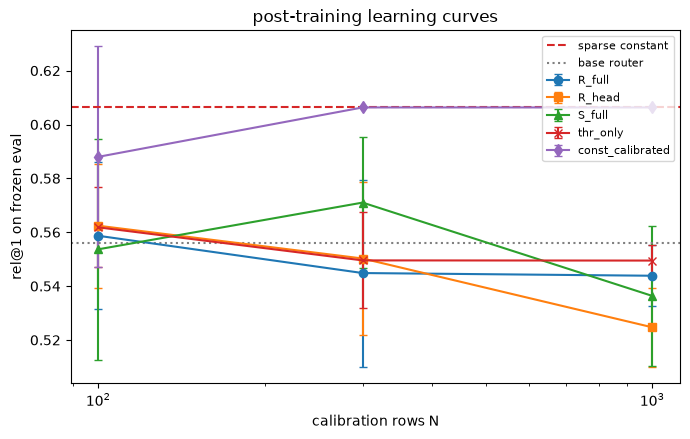

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
for arm, marker in (("R_full", "o"), ("R_head", "s"), ("S_full", "^"),
                    ("thr_only", "x"), ("const_calibrated", "d")):
    rows = res[res["arm"] == arm].groupby("N")["rel1"].agg(["mean", "std"])
    if rows.empty:
        continue
    ax.errorbar(rows.index, rows["mean"], yerr=rows["std"], label=arm,
                marker=marker, capsize=3)
ax.axhline(sparse_bar, color="tab:red", ls="--", label="sparse constant")
base_rel1 = float(res.loc[res["arm"] == "base_router", "rel1"].iloc[0])
ax.axhline(base_rel1, color="gray", ls=":", label="base router")
ax.set_xscale("log")
ax.set_xlabel("calibration rows N")
ax.set_ylabel("rel@1 on frozen eval")
ax.legend(fontsize=8)
ax.set_title("post-training learning curves")
plt.tight_layout()


In [18]:
from scipy.stats import wilcoxon

sparse_vec = eval_metrics["rel1_sparse_only"].to_numpy()


def decide(arm: str, N: int = 1_000) -> dict:
    rel1 = res[(res["arm"] == arm) & (res["N"] == N)].set_index("seed")["rel1"]
    if rel1.empty:
        return {"arm": arm, "verdict": "not run"}
    deltas = rel1 - sparse_bar
    median_seed = rel1.sort_values().index[len(rel1) // 2]
    served = served_store[(arm, N, int(median_seed))]
    diff = per_query(served, eval_ids, "rel1") - sparse_vec
    p = float(wilcoxon(diff, zero_method="zsplit").pvalue) if diff.any() else 1.0
    beats = (deltas.mean() > 0 and (np.sign(deltas) == np.sign(deltas.mean())
                                    ).sum() >= 4 and p < 0.05)
    return {"arm": arm, "mean_d": round(float(deltas.mean()), 4),
            "sd": round(float(deltas.std()), 4),
            "same_sign": int((np.sign(deltas) == np.sign(deltas.mean())).sum()),
            "wilcoxon_p": round(p, 5),
            "verdict": "BEATS CONSTANT" if beats else "does not beat constant"}


verdicts = pd.DataFrame([decide(a) for a in
                         ("R_full", "R_head", "S_full", "thr_only", "placebo")])
print(verdicts.to_string(index=False))

r_row = verdicts.set_index("arm").loc["R_full"]
s_row = verdicts.set_index("arm").loc["S_full"]
if s_row["verdict"] != "not run":
    gap = abs(float(r_row["mean_d"]) - float(s_row["mean_d"]))
    pooled_sd = float(np.sqrt((r_row["sd"] ** 2 + s_row["sd"] ** 2) / 2))
    eps = max(0.015, pooled_sd)
    transfer = (float(s_row["mean_d"])
                / float(r_row["mean_d"])) if r_row["mean_d"] else float("nan")
    print(f"\nS vs R: |gap|={gap:.4f} eps={eps:.4f} -> "
          f"{'S ≈ R' if gap <= eps else 'S differs from R'} "
          f"| transfer ratio={transfer:.2f}")

placebo_v = verdicts.set_index("arm").loc["placebo", "verdict"]
print("\nvalidity check — placebo must not beat the constant:",
      "OK" if placebo_v != "BEATS CONSTANT" else "FAILED — experiment invalid")


     arm  mean_d     sd  same_sign  wilcoxon_p                verdict
  R_full -0.0625 0.0113          5     0.02850 does not beat constant
  R_head -0.0816 0.0147          5     0.00469 does not beat constant
  S_full -0.0700 0.0259          5     0.04764 does not beat constant
thr_only -0.0569 0.0059          5     0.05295 does not beat constant
 placebo -0.0664 0.0212          5     0.02031 does not beat constant

S vs R: |gap|=0.0075 eps=0.0200 -> S ≈ R | transfer ratio=1.12

validity check — placebo must not beat the constant: OK


In [19]:
# mint-vs-real distribution shift (measured, never conditioned on)
if LABELS_MINTED.exists():
    from encoder_router.table import LexicalShape

    def profile(texts: pd.Series, name: str) -> pd.Series:
        z = ZipfStats().frame(texts.reset_index(drop=True))
        sh = LexicalShape().frame(texts.reset_index(drop=True))
        row = pd.concat([z.mean(), sh.mean()])
        row["length_words"] = texts.str.split().str.len().mean()
        row.name = name
        return row

    shift = pd.DataFrame([
        profile(frame_real.loc[cal_ids, "query"], "real_calibration"),
        profile(frame_minted["query"], "minted"),
    ]).T.round(3)
    shift["delta"] = (shift["minted"] - shift["real_calibration"]).round(3)
    print(shift.to_string())
else:
    print("no minted labels yet")


                            real_calibration  minted  delta
zipf.min                               2.627   2.753  0.126
zipf.mean                              3.864   4.257  0.393
zipf.max                               4.953   5.608  0.655
zipf.rare_share                        0.205   0.111 -0.094
zipf.oov_share                         0.072   0.016 -0.056
shape.digit_share                      0.039   0.038 -0.001
shape.symbol_share                     0.007   0.005 -0.002
shape.upper_share                      0.012   0.004 -0.008
shape.max_token_len                    7.263   8.184  0.921
shape.symbolic_token_share             0.098   0.105  0.007
length_words                           3.254   5.727  2.473
